This notebook makes a background image by stitching together images from the Jan 2024 dataset.  This is intended to be run after script #4 with minor modification (all images specially saved)

In [ ]:
%run -i ../src/General_Data/Analysis/Data_Classes.py
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2024_571.return_params()
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2024_241.return_params()

pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = March_2024_571.return_params()
# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = March_2024_241.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = April_2024_571.return_params()
# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = April_2024_241.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = June_2024_571.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = October_2024_571.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2025_241.return_params()
# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2025_571.return_params()

pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = test_571_smoke.return_params()
# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = test_241.return_params()


## Import Statements

In [3]:
import numpy as np
import os
import concurrent
import pandas as pd
from Image_Analysis import *
from scipy import stats

## Manipulate Inputs

In [4]:
screen_nickname = screen.split(':')[2]
os.makedirs(save_loc, exist_ok=True)

## Load data

In [5]:
all_images = np.load(save_loc + 'total_images_stack_' + screen_nickname + '.npy')
bg_cropp = np.load(save_loc + 'background_' + screen_nickname + '.npy')
all_data = pd.read_pickle(save_loc + 'total_data_stack_' + screen_nickname + '.pkl')

In [6]:
len(all_images)

3

In [7]:
all_img_list = [all_images[i,:,:] for i in range(len(all_images))]

## Pixel Calibration

In [8]:
pxcal = pd.unique(all_data[screen.split('Image:')[0] + 'RESOLUTION']).astype(float)
pxcal = pxcal[~np.isnan(pxcal)]
if len(pxcal)>1:
    raise ValueError("more than one pixel calibration")
else:
    pxcal = float(pxcal)

/tmp/ipykernel_616248/4256779235.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pxcal = float(pxcal)


In [9]:
pxcal

11.1732

In [ ]:
def cutout_beam(img1,cutout):
    img = copy.deepcopy(img1)
    img[cutout[2]:cutout[3],cutout[0]:cutout[1]] = np.nan
    return img
    

In [ ]:
cutout = [500-225,500-150,0,500]
img5 = cutout_beam(all_img_list[335],cutout)
plt.imshow(img5)

In [25]:
# cutout = [0,350,125,275]
# img3 = cutout_beam(img1,cutout)
# plt.imshow(img3)

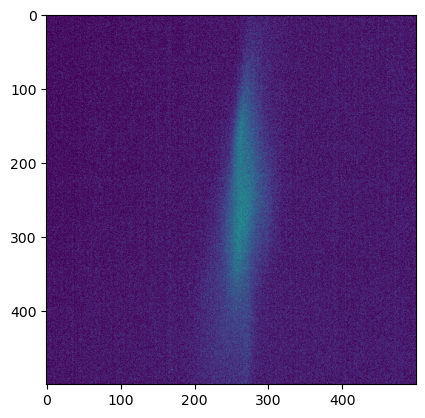

In [26]:
plt.imshow(all_img_list[285])

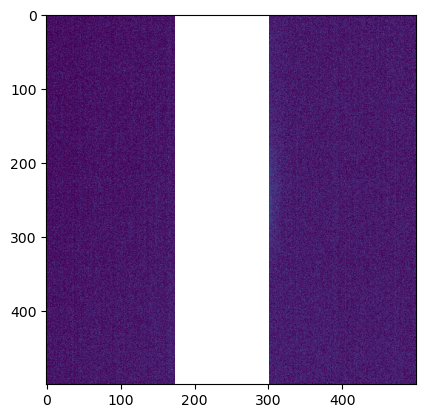

In [27]:
cutout = [500-325,500-200,0,500]
img4 = cutout_beam(all_img_list[285],cutout)
plt.imshow(img4)

In [28]:
# plt.imshow(total_images[230],vmax=50)

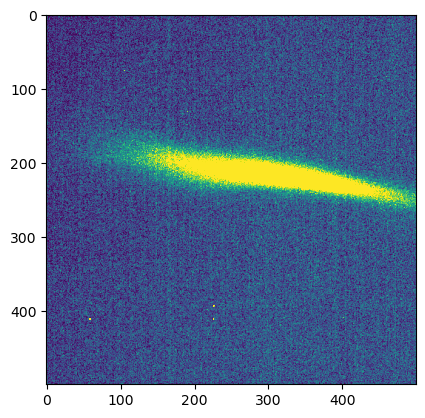

In [29]:
img6 = all_img_list[230]
plt.imshow(img6,vmax=50)

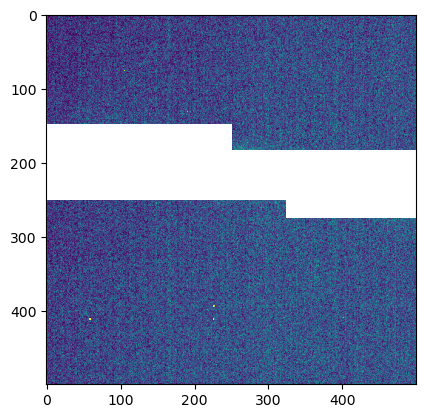

In [30]:

cutout = [500-250,500-175,185,250]
img7 = cutout_beam(img6,cutout)
cutout = [500-175,500-0,185,275]
img7 = cutout_beam(img7,cutout)
cutout = [500-500,500-250,150,250]
img7 = cutout_beam(img7,cutout)
plt.imshow(img7,vmax=50)

In [31]:

img8 = all_img_list[237]

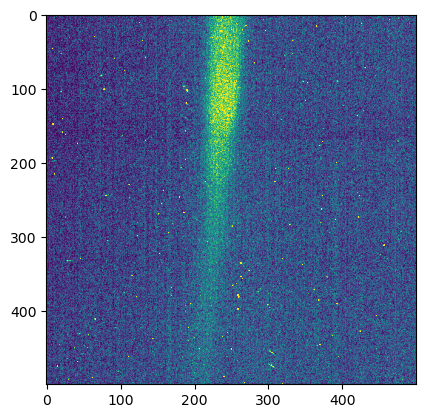

In [32]:
plt.imshow(img8,vmax=50)


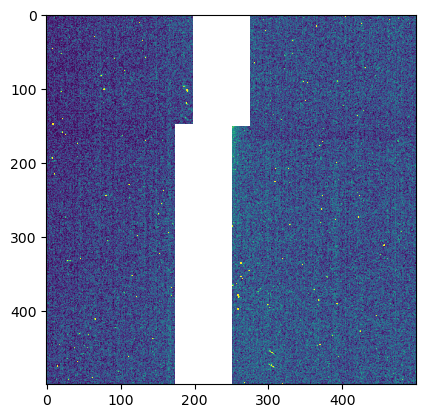

In [33]:
cutout = [500-300,500-225,0,150]
img8 = cutout_beam(img8,cutout)

cutout = [500-325,500-250,150,500]
img8 = cutout_beam(img8,cutout)

plt.imshow(img8,vmax=50)


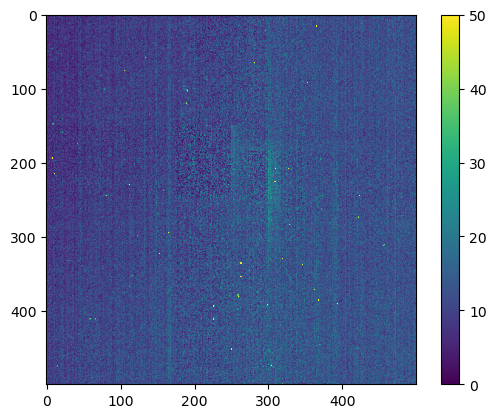

In [34]:
stacked = np.stack([ img4,img5,img7,img8], axis=0)
img_bg = np.nanmean(stacked,axis=0)
plt.imshow(img_bg,vmax=50)
plt.colorbar()

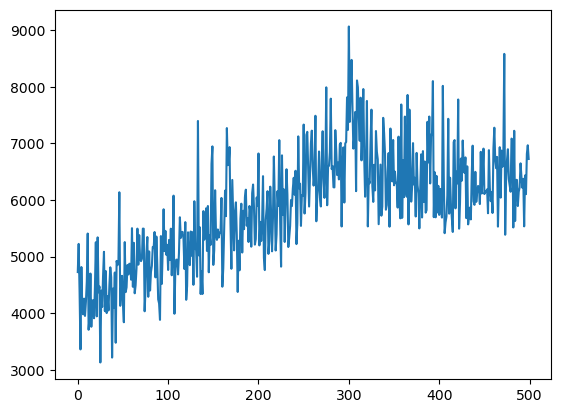

In [35]:
plt.plot(np.sum(img_bg,axis=0))

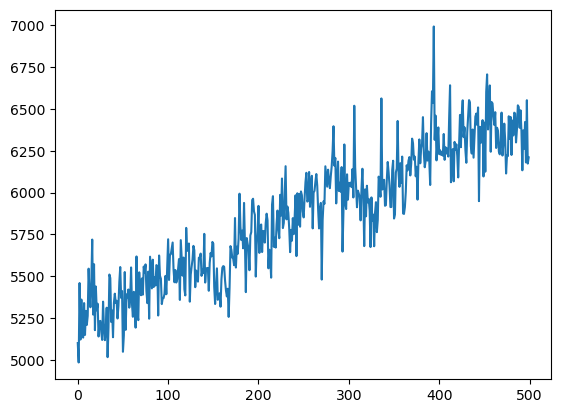

In [36]:
plt.plot(np.sum(img_bg,axis=1))

In [37]:
np.save(save_loc + 'background_' + screen_nickname + '.npy',img_bg)
